# Storage class — reconstruction from demand, and what storage links are good for

The sanity notebook split flow links into **demand-class** (district demand explains them) and
**storage-class** (storage state explains what demand cannot: $U_s>R^2_{\text{dem}}$). This notebook tests
that split on **every flow link** (pump links excluded) of **every ok target world** of a study, keeping
every result **per world** (one world = one drift client); partition summaries sit beside, never instead.

| block | question |
|---|---|
| 0 · classes | the four sets (tier × class); does a link keep its class whichever district drifts? |
| R1 · out-of-sample | fitted on the transition span, does a demand mixture predict the held-out settled window? |
| R2 · same link, other worlds | is a link's coefficient on district $k$ the same whether $k$ drifted or not? |
| R3 · the current labels | do the label stack's native gains rebuild every link, init and settled? |
| R4 · storage links | do demand **plus** hub state predict the held-out window where demand alone fails? |
| S1 · detection | does a link detect the drift, how early — and do the negative controls stay silent? |
| S2 · attribution | do the drift's effects on storage links differ between drifting districts? |
| S3 · hub readout | which pump / tank does each storage link observe, and how well? |

**Known confound — established by `partition_consistency`.** The partition changes the pre-drift
world: `income_landuse_mapping` is **positional** (one income / land-use code per district, in district
order), so under another partition the same node gets another code. Init demand differs at every node from
day 0 between partitions (identical within), and on D-Town the pump regime differs with it. Comparisons
**between partitions** therefore mix the districting with a different city; comparisons **within** a
partition are clean.

**Not here.** No lag / causality test (the transition-month estimator failed its positive control and is
being rebuilt). Probe worlds are left out: they are near-duplicates of the targets.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater.placement import mixture_probe as mp, signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = None                    # None -> the latest study
ATLAS = Atlas(root=EXPERIMENTS)
STUDY = STUDY or ATLAS.studies()[1]
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
print(f"study {STUDY}: {len(WORLDS)} ok worlds")
display(WORLDS.groupby(["network", "districting", "drift_district"]).size().rename("worlds")
        .reset_index())

study ky72_districting_all_districts: 12 ok worlds


,network,districting,drift_district,worlds
0,ky72,fast_greedy,District_A,1
1,ky72,fast_greedy,District_B,1
2,ky72,fast_greedy,District_C,1
3,ky72,fast_greedy,District_D,1
4,ky72,girvan_newman,District_A,1
5,ky72,girvan_newman,District_B,1
6,ky72,girvan_newman,District_C,1
7,ky72,girvan_newman,District_D,1
8,ky72,spectral,District_A,1
9,ky72,spectral,District_B,1


### Helpers and windows

Windows follow `verify_placement`: **init** = the baseline window; **transition span** = one month before
the first scheduled switch to the start of the settled window; **settled** = from the later of the settle
month and the drift's completion to the horizon. Flows are raw, `.inp` orientation, hourly (the model
resolution). A tank's net inflow is the signed sum of its incident link flows. Fits are ordinary least
squares with an intercept.

In [2]:
FLOW = "flow"


def target_probe(w):
    sch = w.catalog.load("gt_drift_schedule")
    if sch is None or not len(sch):
        return None
    tgt = str(sch.sort_values("drift_month")["district"].iloc[0])
    dy = w.catalog.load("districts")
    return sp.Probe(districts=dy["districts"], assets=dy.get("assets") or {},
                    demand=w.catalog.load("demand_series"), pressures=pd.DataFrame(),
                    flows=w.catalog.load("flows"), schedule=sch, time=w.params["time"],
                    params={"patterns": w.params["patterns"]}, drift={"tgt_district": tgt},
                    label=w.sim_hash)


def target_windows(P, settle, patterns):
    sm, n = P.steps_month, int(P.time["n_months"])
    if float((patterns or {}).get("seasonality_scale", 0.0)) > 0:
        return mp.season_windows(P, pad=int(settle["pad"]))
    final0 = int(P.phases()["final"][0])
    try:
        s_lo, _ = mp.settled_window(P, ref_months=int(settle["ref_months"]),
                                    slack=float(settle["slack"]), pad=int(settle["pad"]),
                                    min_months=0)
        start = max(s_lo // sm, final0)
    except ValueError:
        start = final0
    need = int(settle.get("min_months", 3))
    if n - start < need:
        raise ValueError(f"unsettled: {n - start} settled month(s), {need} needed")
    return mp.baseline_window(P), (start * sm, n * sm)


def storage_map(wn, cols):
    cols = set(cols)
    pumps = [p for p in wn.pump_name_list if p in cols]
    tanks = {}
    for t in wn.tank_name_list:
        inc = [(ln, 1.0 if wn.get_link(ln).end_node_name == t else -1.0)
               for ln in wn.get_links_for_node(t) if ln in cols]
        if inc:
            tanks[t] = inc
    return pumps, tanks


def storage_frame(P, pumps, tanks):
    X = {f"pump:{p}": P.flows[p].to_numpy(float) for p in pumps}
    for t, inc in tanks.items():
        X[f"tank:{t}"] = np.sum([s * P.flows[ln].to_numpy(float) for ln, s in inc], axis=0)
    return pd.DataFrame(X, index=P.flows.index)


def pump_on(q):
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def ols(X, Y):
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return B


def r2(Y, Yhat):
    # plain R^2 per column (out of sample it can be negative)
    tot = ((Y - Y.mean(axis=0)) ** 2).sum(axis=0)
    res = ((Y - Yhat) ** 2).sum(axis=0)
    return np.where(tot > 1e-12, 1.0 - res / np.where(tot > 1e-12, tot, 1.0), np.nan)


def adj(r, n, p):
    return 1.0 - (1.0 - r) * (n - 1) / max(n - p - 1, 1)


def ratio(a, b):
    return np.where(np.abs(b) > 1e-12, a / np.where(np.abs(b) > 1e-12, b, 1.0), np.nan)


def vif(D):
    # variance inflation of each column of D against the others (with intercept)
    out = []
    for k in range(D.shape[1]):
        others = np.column_stack([np.ones(len(D)), np.delete(D, k, axis=1)])
        rk = r2(D[:, [k]], others @ ols(others, D[:, [k]]))[0]
        out.append(1.0 / max(1.0 - rk, 1e-12))
    return np.array(out)


def monthly_profiles(Q, P, months):
    sm, sd = P.steps_month, P.steps_day
    return {m: np.atleast_2d(sp.weekly_profile(Q[m * sm:(m + 1) * sm], sd, step0=m * sm))
            for m in months}

## One pass over every world

Per world: the label stack (`w.label()`, for the tier, home district and native gains), the world's own
series, its three windows, and every flow link that is not a pump. Everything below is computed here and
kept per world; the following cells only read and display.

`PERSIST` and the null used by S1 are defined in the S1 section; they are set here so the pass is one cell.

In [3]:
PERSIST = 3          # S1: consecutive months above the null to count as a detection

ROWS, COEF, EFF, HUB, WMETA, issues = [], [], [], [], [], []
for wi, r in WORLDS.iterrows():
    h = r["sim_hash"]
    try:
        w = ATLAS.world(h)
        L = w.label()
        if L is None:
            raise ValueError("no label stack (manual sensors)")
        P = target_probe(w)
        if P is None:
            raise ValueError("no drift")
        (i0, i1), (f0, f1) = target_windows(P, w.params["sensor_placement"]["probe"]["settle"],
                                            w.params["patterns"])
        sm, sd = P.steps_month, P.steps_day
        first = int(P.phases()["init"][1])
        tlo, thi = max(first - 1, 0) * sm, f0
        wn = w.network_model
        pumps, tanks = storage_map(wn, P.flows.columns)
        M = L.mixture[L.mixture["kind"] == FLOW][["id", "element", "home", "tier", "purity"]].copy()
        M = M[~M["element"].astype(str).isin(set(wn.pump_name_list))]
        M = M[M["element"].astype(str).isin(P.flows.columns)].reset_index(drop=True)
        els = M["element"].astype(str).tolist()
        names = P.names
        drift = P.drift["tgt_district"]
        meta = {"network": r["network"], "districting": r["districting"], "world": h[:8],
                "drift": drift}

        Q = P.flows[els].to_numpy(float)
        D = P.district_demand[names].to_numpy(float)
        Sf = storage_frame(P, pumps, tanks)
        S = Sf.to_numpy(float)
        one = lambda a, b: np.ones((b - a, 1))

        # ---- classes over the transition span (adjusted R^2, as the sanity notebook) ----
        Yt, Dt, St = Q[tlo:thi], D[tlo:thi], S[tlo:thi]
        Xd = np.column_stack([one(tlo, thi), Dt])
        Xs = np.column_stack([one(tlo, thi), St])
        Xf = np.column_stack([Xd, St])
        n_t = thi - tlo
        Bd, Bs, Bf = ols(Xd, Yt), ols(Xs, Yt), ols(Xf, Yt)
        r2d = adj(r2(Yt, Xd @ Bd), n_t, Xd.shape[1] - 1)
        r2s = adj(r2(Yt, Xs @ Bs), n_t, Xs.shape[1] - 1)
        r2f = adj(r2(Yt, Xf @ Bf), n_t, Xf.shape[1] - 1)
        Us = r2f - r2d

        # ---- R1 / R4: transition-fitted models, predicted on held-out windows ----------
        Yf, Yi = Q[f0:f1], Q[i0:i1]
        pd_f = np.column_stack([one(f0, f1), D[f0:f1]]) @ Bd
        pd_i = np.column_stack([one(i0, i1), D[i0:i1]]) @ Bd
        pf_f = np.column_stack([one(f0, f1), D[f0:f1], S[f0:f1]]) @ Bf
        ps_f = np.column_stack([one(f0, f1), S[f0:f1]]) @ Bs
        r1_fit, r1_out, r1_back = r2(Yt, Xd @ Bd), r2(Yf, pd_f), r2(Yi, pd_i)
        r4_full, r4_sto = r2(Yf, pf_f), r2(Yf, ps_f)
        r1_lam = ratio(pd_f.mean(axis=0), Yf.mean(axis=0))

        # ---- R3: label native gains, intercept-only refit per window --------------------
        G = L.gains[L.gains["kind"] == FLOW]
        A_lab = (G.assign(a=G["proj_native"] / G["excite_native"])
                 .pivot(index="id", columns="drift_district", values="a")
                 .reindex(index=M["id"], columns=names).to_numpy(float))
        def lab_fit(lo, hi):
            base = D[lo:hi] @ np.nan_to_num(A_lab.T)
            Y = Q[lo:hi]
            c = (Y - base).mean(axis=0)
            return r2(Y, base + c), ratio(base.mean(axis=0), Y.mean(axis=0))
        r3i, l3i = lab_fit(i0, i1)
        r3f, l3f = lab_fit(f0, f1)

        # ---- S1: monthly profile change against the init months' own spread ------------
        n_m = int(P.time["n_months"])
        init_m = list(range(1, first))                    # month 0 excluded: start-up transient
        if len(init_m) < 3:
            raise ValueError(f"only {len(init_m)} init months for the S1 null")
        PROF = monthly_profiles(Q, P, range(n_m))
        Pin = np.stack([PROF[m] for m in init_m])          # (m_init, g, T)
        Pbar = Pin.mean(axis=0)
        loo = np.stack([np.linalg.norm(Pin[j] - (Pin.sum(0) - Pin[j]) / (len(init_m) - 1), axis=1)
                        for j in range(len(init_m))])      # (m_init, g)
        thr = loo.max(axis=0)
        score = np.stack([np.linalg.norm(PROF[m] - Pbar, axis=1) for m in range(n_m)])  # (n_m, g)
        above = score > thr[None, :]
        det = np.full(len(els), np.nan)
        for g_ in range(len(els)):
            run = 0
            for m in range(first, n_m):
                run = run + 1 if above[m, g_] else 0
                if run >= PERSIST:
                    det[g_] = m - PERSIST + 1
                    break
        settled_m = list(range(f0 // sm, n_m))
        eff_ratio = np.median(score[settled_m], axis=0) / np.where(thr > 0, thr, np.nan)

        # ---- S2: standardised level change, settled vs init -----------------------------
        mmean = np.stack([Q[m * sm:(m + 1) * sm].mean(axis=0) for m in range(n_m)])
        e_lvl = (mmean[settled_m].mean(axis=0) - mmean[init_m].mean(axis=0)) / \
                np.where(mmean[init_m].std(axis=0) > 1e-12, mmean[init_m].std(axis=0), np.nan)

        # ---- S3: which hub element each link observes (settled window, hourly) ---------
        hub_cols, hub_X = [], []
        for p in pumps:
            on = pump_on(P.flows[p].to_numpy(float))[f0:f1].astype(float)
            if on.std() > 0:
                hub_cols.append(f"pump:{p}"); hub_X.append(on)
        for t in tanks:
            x = Sf[f"tank:{t}"].to_numpy(float)[f0:f1]
            if x.std() > 0:
                hub_cols.append(f"tank:{t}"); hub_X.append(x)
        if hub_cols:
            Hz = np.column_stack(hub_X)
            Hz = (Hz - Hz.mean(0)) / Hz.std(0)
            Qz = (Yf - Yf.mean(0)) / np.where(Yf.std(0) > 1e-12, Yf.std(0), np.nan)
            R2h = (Qz.T @ Hz / len(Hz)) ** 2                # (g, n_hub)
            best = np.nanargmax(np.nan_to_num(R2h, nan=-1), axis=1)
            best_r2 = R2h[np.arange(len(els)), best]
        else:
            best, best_r2 = np.zeros(len(els), int), np.full(len(els), np.nan)

        # ---- per-world meta: demand collinearity over the transition span ---------------
        v = vif(Dt)
        WMETA.append({**meta, "first_month": first, "settled_month": f0 // sm,
                      "n_links": len(els), "n_pumps": len(pumps), "n_tanks": len(tanks),
                      **{f"VIF_{d}": v[k] for k, d in enumerate(names)}})

        for g_, row in M.iterrows():
            ROWS.append({**meta, "id": row["id"], "element": row["element"], "home": row["home"],
                         "tier": row["tier"], "purity": row["purity"],
                         "rel": "own" if row["home"] == drift else "other",
                         "R2_dem": r2d[g_], "R2_sto": r2s[g_], "R2_full": r2f[g_], "U_s": Us[g_],
                         "storage": bool(Us[g_] > r2d[g_]),
                         "R1_fit": r1_fit[g_], "R1_out": r1_out[g_], "R1_back": r1_back[g_],
                         "R1_lam": r1_lam[g_],
                         "R4_out_full": r4_full[g_], "R4_out_sto": r4_sto[g_],
                         "R3_init": r3i[g_], "R3_final": r3f[g_],
                         "R3_lam_init": l3i[g_], "R3_lam_final": l3f[g_],
                         "S1_det_month": det[g_], "S1_lag": det[g_] - first,
                         "S1_eff": eff_ratio[g_], "S2_level": e_lvl[g_],
                         "S3_hub": hub_cols[best[g_]] if hub_cols else None,
                         "S3_r2": best_r2[g_]})
            for k, d in enumerate(names):
                COEF.append({**meta, "id": row["id"], "home": row["home"], "tier": row["tier"],
                             "district": d, "own": d == drift, "a": Bd[1 + k, g_],
                             "a_label": A_lab[g_, k], "VIF": v[k]})
        print(f"\r  {wi + 1}/{len(WORLDS)} worlds — {r['districting']} {drift}      ",
              end="", flush=True)
        del P, Q, D, S, Sf, PROF
    except Exception as exc:                              # reported, never swallowed silently
        issues.append({"world": h[:8], "districting": r["districting"],
                       "drift": r["drift_district"], "issue": f"{type(exc).__name__}: {exc}"[:200]})
print()
R = pd.DataFrame(ROWS)
C = pd.DataFrame(COEF)
WM = pd.DataFrame(WMETA)
if issues:
    display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))

R["core"] = np.where(R["tier"] == "core", "core", np.where(R["tier"] == "unusable", "unusable", "non-core"))
R["set"] = np.where(R["core"] == "unusable", "unusable",
                    R["core"] + " · " + np.where(R["storage"], "storage", "demand"))
SETS = ["core · demand", "non-core · demand", "core · storage", "non-core · storage"]
WKEY = ["network", "districting", "drift", "world"]
display(WM.round(2))
print("VIF_k: collinearity of district k's demand with the others over the transition span "
      "(1 = independent; large = its coefficient is poorly identified in that world).")

  12/12 worlds — spectral District_D          


,network,districting,world,drift,first_month,settled_month,n_links,n_pumps,n_tanks,VIF_District_A,VIF_District_B,VIF_District_C,VIF_District_D
0,ky72,fast_greedy,0b4750d3,District_A,12,51,603,1,3,2.04,3.00,38.35,41.17
1,ky72,fast_greedy,13f0f426,District_B,12,35,603,1,3,2.88,1.73,38.76,41.45
2,ky72,fast_greedy,312ef90c,District_C,12,32,603,1,3,761.77,762.13,2.84,2.52
3,ky72,fast_greedy,8a9b36d7,District_D,12,33,603,1,3,752.66,751.66,1.16,1.91
4,ky72,girvan_newman,35d8d9bc,District_A,12,54,603,1,3,2.11,3.03,37.09,39.80
5,ky72,girvan_newman,420262ff,District_B,12,31,603,1,3,2.82,1.84,37.18,39.98
6,ky72,girvan_newman,13e16814,District_C,12,46,603,1,3,722.56,722.97,2.97,2.74
7,ky72,girvan_newman,f90a7f06,District_D,12,27,603,1,3,723.67,720.21,1.32,2.24
8,ky72,spectral,27ccb25e,District_A,12,50,603,1,3,1.78,2.58,37.72,40.49
9,ky72,spectral,dabef050,District_B,12,50,603,1,3,2.63,1.92,37.68,40.45


VIF_k: collinearity of district k's demand with the others over the transition span (1 = independent; large = its coefficient is poorly identified in that world).


## 0 — classes

Per world, every link is placed in one of four sets by its **tier** (from the label stack: `core` vs
transition/foreign) and its **class** in that world (`storage` if $U_s>R^2_{\text{dem}}$ over the
transition span):

| set | meaning |
|---|---|
| core · demand | the classic pure link: one district's demand |
| **non-core · demand** | candidate genuine **demand mixing** — the set the mixed slots were meant to draw from |
| core · storage | looks pure, reads storage — a district fed by its own tank |
| non-core · storage | reads the storage hub |

**Stability.** A link's class should not depend on which district drifted. Per partition, a link is
`always storage`, `always demand` or `switches` across that partition's worlds.

In [4]:
display(Markdown("**Links per set — per world**"))
display(R.pivot_table(index=WKEY, columns="set", values="id", aggfunc="count", fill_value=0)
        .reindex(columns=SETS + ["unusable"], fill_value=0))
st = (R.groupby(["network", "districting", "id", "tier"])["storage"]
      .agg(n_worlds="size", share="mean").reset_index())
st["stability"] = np.select([st["share"] == 1, st["share"] == 0], ["always storage", "always demand"],
                            "switches")
display(Markdown("**Class stability across the worlds of a partition** (links)"))
display(st.pivot_table(index=["network", "districting"], columns="stability", values="id",
                       aggfunc="count", fill_value=0))
display(Markdown("**Links that switch class** — which worlds call them storage"))
sw = st[st["stability"] == "switches"][["network", "districting", "id", "tier", "share"]]
if len(sw):
    who = (R[R["storage"]].groupby(["network", "districting", "id"])["drift"]
           .agg(lambda s: ",".join(sorted(s))).rename("storage_in"))
    display(sw.merge(who, on=["network", "districting", "id"], how="left")
            .sort_values(["network", "districting", "share"]).round(2).reset_index(drop=True))
else:
    print("none")

**Links per set — per world**

set                                        core · demand  non-core · demand  core · storage  non-core · storage  unusable
network districting   drift      world                                                                                   
ky72    fast_greedy   District_A 0b4750d3            228                 45               1                 329         0
                      District_B 13f0f426            228                 50               1                 324         0
                      District_C 312ef90c            227                 43               2                 331         0
                      District_D 8a9b36d7            229                 44               0                 330         0
        girvan_newman District_A 35d8d9bc            242                 47              11                 303         0
                      District_B 420262ff            243                 56              10                 294         0
                      District_C 13e16814            240                 39              13                 311         0
                      District_D f90a7f06            240                 43              13                 307         0
        spectral      District_A 27ccb25e            239                 41               2                 321         0
                      District_B dabef050            238                 44               3                 318         0
                      District_C 44043280            237                 41               4                 321         0
                      District_D d767277b            237                 42               4                 320         0

**Class stability across the worlds of a partition** (links)

stability              always demand  always storage  switches
network districting                                           
ky72    fast_greedy              267             320        16
        girvan_newman            276             299        28
        spectral                 275             316        12

**Links that switch class** — which worlds call them storage

,network,districting,id,tier,share,storage_in
0,ky72,fast_greedy,q_P-307,core,0.25,District_C
1,ky72,fast_greedy,q_P-452,transition,0.25,District_D
2,ky72,fast_greedy,q_P-519,transition,0.25,District_D
3,ky72,fast_greedy,q_P-77,transition,0.25,District_C
4,ky72,fast_greedy,q_P-147,transition,0.50,"District_A,District_B"
5,ky72,fast_greedy,q_P-29,transition,0.50,"District_B,District_C"
6,ky72,fast_greedy,q_P-153,transition,0.75,"District_A,District_C,District_D"
7,ky72,fast_greedy,q_P-167,transition,0.75,"District_B,District_C,District_D"
8,ky72,fast_greedy,q_P-182,core,0.75,"District_A,District_B,District_C"
9,ky72,fast_greedy,q_P-208,transition,0.75,"District_A,District_C,District_D"


## R1 — a demand mixture fitted on the transition span, tested on held-out windows

Per world and link: $Q_s\approx c+\sum_k a_k D_k$ fitted by OLS on the transition span (hourly), then
applied **unchanged** to the settled window (forward, out of sample) and the init window (backward).

| column | definition | reading |
|---|---|---|
| `R1_fit` | $R^2$ on the transition span (in sample) | how well a fixed mixture describes the link while the drift happens |
| `R1_out` | $R^2$ on the settled window, same coefficients | ≈ `R1_fit` = the mixture holds after the drift; ≪ = it does not; < 0 = worse than the window mean |
| `R1_back` | $R^2$ on the init window, same coefficients | the same test backwards |
| `R1_lam` | mean prediction / mean flow, settled | ≈ 1 = right volume; meaningless where the mean flow is ≈ 0 (fill/draw links) |

A genuine demand mixture predicts both held-out windows; a storage link should not (its flow depends on
hub state the model does not have — R4 adds it). Tables: one row per world, sets as columns.

**R1_fit — median per world and set** (q10 / q90 in the next table)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.932              0.664           0.417               0.102
                      District_B 13f0f426          0.920              0.658           0.471               0.097
                      District_C 312ef90c          0.903              0.678           0.394               0.127
                      District_D 8a9b36d7          0.939              0.701             NaN               0.138
        girvan_newman District_A 35d8d9bc          0.882              0.657           0.266               0.197
                      District_B 420262ff          0.913              0.671           0.301               0.224
                      District_C 13e16814          0.913              0.678           0.207               0.171
                      District_D f90a7f06          0.933              0.682           0.296               0.198
        spectral      District_A 27ccb25e          0.898              0.722           0.218               0.130
                      District_B dabef050          0.907              0.689           0.328               0.123
                      District_C 44043280          0.926              0.703           0.256               0.140
                      District_D d767277b          0.926              0.701           0.305               0.176

**R1_out — median per world and set** (q10 / q90 in the next table)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.930              0.635           0.536               0.022
                      District_B 13f0f426          0.919              0.540           0.574               0.027
                      District_C 312ef90c          0.876              0.690           0.306               0.177
                      District_D 8a9b36d7          0.935              0.646             NaN               0.134
        girvan_newman District_A 35d8d9bc          0.888              0.670           0.221               0.090
                      District_B 420262ff          0.905              0.642           0.186               0.191
                      District_C 13e16814          0.917              0.691           0.225               0.178
                      District_D f90a7f06          0.930              0.686           0.284               0.205
        spectral      District_A 27ccb25e          0.825              0.685           0.198               0.093
                      District_B dabef050          0.905              0.428           0.336              -0.010
                      District_C 44043280          0.924              0.711           0.271               0.144
                      District_D d767277b          0.924              0.717           0.366               0.221

**R1_back — median per world and set** (q10 / q90 in the next table)

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.929              0.558           0.386               0.132
                      District_B 13f0f426          0.929              0.543           0.393               0.142
                      District_C 312ef90c          0.917              0.616           0.441               0.146
                      District_D 8a9b36d7          0.934              0.550             NaN               0.158
        girvan_newman District_A 35d8d9bc          0.880              0.475           0.178               0.145
                      District_B 420262ff          0.913              0.514           0.215               0.159
                      District_C 13e16814          0.925              0.586           0.259               0.173
                      District_D f90a7f06          0.922              0.589           0.205               0.175
        spectral      District_A 27ccb25e          0.879              0.565          -0.015               0.121
                      District_B dabef050          0.919              0.531           0.291               0.112
                      District_C 44043280          0.921              0.610           0.263               0.141
                      District_D d767277b          0.920              0.607           0.264               0.145

**R1_out — q10 / median / q90 per partition and set** (summary)

count    10%    50%    90%
network districting   set                                            
ky72    fast_greedy   core · demand        912.0  0.210  0.921  0.992
                      core · storage         4.0  0.293  0.438  0.563
                      non-core · demand    170.0  0.371  0.647  0.916
                      non-core · storage  1314.0 -0.000  0.091  0.273
        girvan_newman core · demand        965.0  0.110  0.910  0.989
                      core · storage        47.0 -0.002  0.236  0.451
                      non-core · demand    175.0  0.357  0.675  0.941
                      non-core · storage  1215.0  0.027  0.175  0.356
        spectral      core · demand        951.0  0.297  0.911  0.990
                      core · storage        13.0  0.172  0.300  0.413
                      non-core · demand    156.0  0.340  0.675  0.926
                      non-core · storage  1280.0 -0.026  0.119  0.313

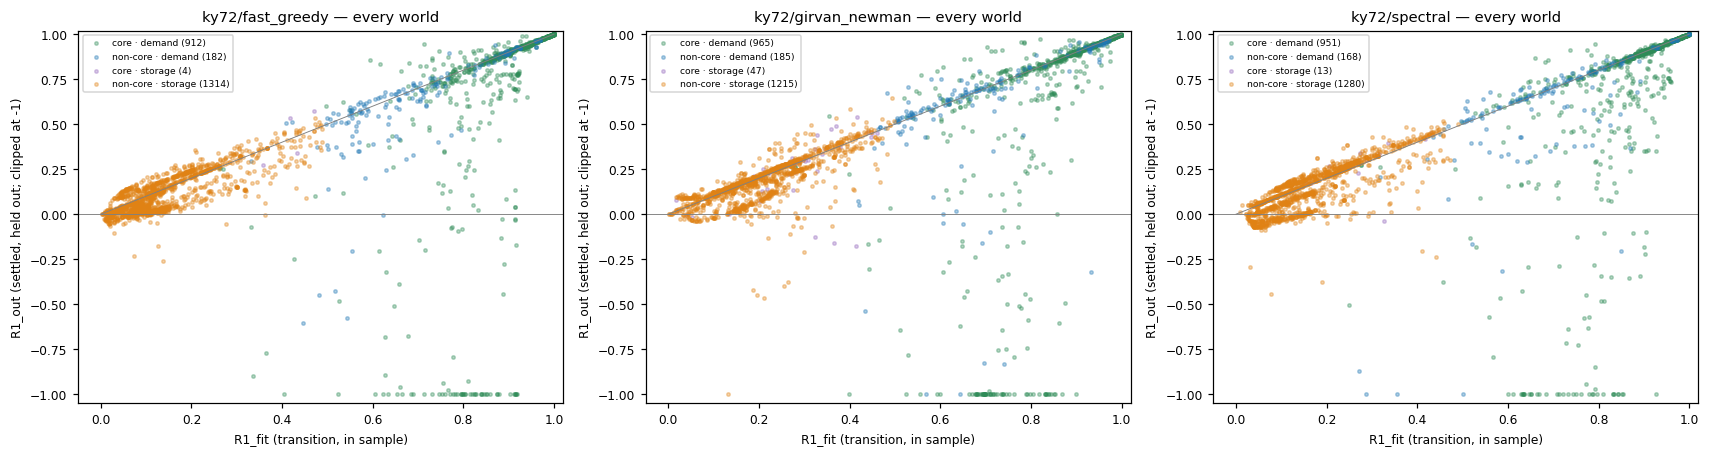

In [5]:
for col in ("R1_fit", "R1_out", "R1_back"):
    display(Markdown(f"**{col} — median per world and set** (q10 / q90 in the next table)"))
    display(R.pivot_table(index=WKEY, columns="set", values=col, aggfunc="median")
            .reindex(columns=SETS).round(3))
display(Markdown("**R1_out — q10 / median / q90 per partition and set** (summary)"))
display(R.groupby(["network", "districting", "set"])["R1_out"]
        .describe(percentiles=[.1, .5, .9])[["count", "10%", "50%", "90%"]].round(3))

parts = R[["network", "districting"]].drop_duplicates().itertuples(index=False)
parts = list(parts)
fig, axes = plt.subplots(1, len(parts), figsize=(5.2 * len(parts), 4.2), squeeze=False)
for ax, (net, meth) in zip(axes[0], parts):
    g = R[(R["network"] == net) & (R["districting"] == meth)]
    for sname, colour in zip(SETS, ("#2e8b57", "#1f77b4", "#9467bd", "#e08214")):
        h = g[g["set"] == sname]
        ax.scatter(h["R1_fit"], h["R1_out"].clip(-1, 1), s=5, alpha=0.35, c=colour,
                   label=f"{sname} ({len(h)})")
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.6); ax.axhline(0, color="0.5", lw=0.6)
    ax.set(xlabel="R1_fit (transition, in sample)", ylabel="R1_out (settled, held out; clipped at -1)",
           title=f"{net}/{meth} — every world", xlim=(-0.05, 1.02), ylim=(-1.05, 1.02))
    ax.legend(fontsize=6)
fig.tight_layout(); plt.show()

## R2 — the same link, the same district, different worlds

In the world where district $k$ drifts, $D_k$ moves while the others do not, so the coefficient $a_k$ is
identified by the drift itself (`own`). In the other worlds of the same partition $D_k$ is static and $a_k$
rests on how its weekly shape differs from the other districts' (watch `VIF`). If the link reads a fixed
mixture, both estimates agree.

| column | definition | reading |
|---|---|---|
| `a_own` | $a_k$ from the world where $k$ drifted | the best-identified estimate |
| `a_other` | median of $a_k$ over the other worlds of the partition | |
| `rel_dev` | $\lvert a_{\text{other}}-a_{\text{own}}\rvert/\lvert a_{\text{own}}\rvert$ | ≈ 0 = a stable mixture coefficient |
| `VIF_other` | median VIF of $D_k$ in those other worlds | large = `a_other` is poorly identified; a large `rel_dev` there is not evidence |
| `rho_label` | Spearman over links of `a_own` vs the label's native gain for $k$ | two estimates of the same quantity from different worlds |

Only pairs with $\lvert a_{\text{own}}\rvert$ above 1% of the largest in that partition are kept — a
relative deviation of a coefficient that is ≈ 0 says nothing.

In [6]:
own = C[C["own"]][["network", "districting", "id", "tier", "district", "a", "a_label"]] \
    .rename(columns={"a": "a_own"})
oth = (C[~C["own"]].groupby(["network", "districting", "id", "district"])
       .agg(a_other=("a", "median"), a_spread=("a", lambda s: s.max() - s.min()),
            VIF_other=("VIF", "median"), n_other=("a", "size")).reset_index())
R2t = own.merge(oth, on=["network", "districting", "id", "district"], how="inner")
cls = R.groupby(["network", "districting", "id"])["storage"].mean().rename("storage_share").reset_index()
R2t = R2t.merge(cls, on=["network", "districting", "id"], how="left")
R2t["class"] = np.select([R2t["storage_share"] == 1, R2t["storage_share"] == 0],
                         ["storage", "demand"], "switches")
R2t["core"] = np.where(R2t["tier"] == "core", "core", "non-core")
big = R2t.groupby(["network", "districting"])["a_own"].transform(lambda s: s.abs().max())
R2t = R2t[R2t["a_own"].abs() > 0.01 * big].copy()
R2t["rel_dev"] = (R2t["a_other"] - R2t["a_own"]).abs() / R2t["a_own"].abs()

display(Markdown("**rel_dev per partition, district and link group** (median; q90 beside)"))
display(R2t.groupby(["network", "districting", "district", "core", "class"])
        .agg(pairs=("id", "size"), rel_dev_med=("rel_dev", "median"),
             rel_dev_q90=("rel_dev", lambda s: s.quantile(.9)),
             VIF_other=("VIF_other", "median")).round(3))
display(Markdown("**Fitted vs label** — Spearman of `a_own` and the label's native gain, per district"))
display(R2t.groupby(["network", "districting", "district"])
        .apply(lambda g: pd.Series({"links": len(g),
                                    "rho_label": g["a_own"].rank().corr(g["a_label"].rank())}))
        .round(3))

**rel_dev per partition, district and link group** (median; q90 beside)

pairs  rel_dev_med  rel_dev_q90  VIF_other
network districting   district   core     class                                               
ky72    fast_greedy   District_A core     demand       14        0.586        4.495    752.661
                                 non-core demand        7        0.398        1.440    752.661
                                          storage     178        0.901        2.206    752.661
                                          switches      4        0.202        0.334    752.661
                      District_B core     demand       40        0.217        0.399    751.663
                                 non-core demand       19        0.269        0.571    751.663
                                          storage     231        3.643       12.966    751.663
                                          switches     12        0.674        7.929    751.663
                      District_C core     demand       53        0.183        0.651     38.354
                                          switches      1        0.545        0.545     38.354
                                 non-core demand        8        0.625        1.249     38.354
                                          storage     229        1.348        1.454     38.354
                                          switches      5        0.918        1.198     38.354
                      District_D core     demand       24        0.302        1.149     41.168
                                          switches      2        0.254        0.362     41.168
                                 non-core demand       20        0.446        5.327     41.168
                                          storage     213        2.788        7.459     41.168
                                          switches      4        1.870        4.487     41.168
        girvan_newman District_A core     demand       50        0.618        1.411    722.559
                                          storage       4        1.085        1.262    722.559
                                 non-core demand       12        0.614        1.502    722.559
                                          storage     221        1.026        3.403    722.559
                                          switches     10        0.409        1.350    722.559
                      District_B core     demand       46        0.199        0.629    720.209
                                          storage       6        0.886        2.970    720.209
                                          switches      3        0.699        0.857    720.209
                                 non-core demand       21        0.302        1.652    720.209
                                          storage     251        4.133        7.236    720.209
                                          switches     14        1.052        1.489    720.209
                      District_C core     demand       27        0.227        3.449     37.087
                                          storage       4        2.178        3.558     37.087
                                          switches      1        0.281        0.281     37.087
                                 non-core demand       10        0.520        3.563     37.087
                                          storage     214        3.169        3.972     37.087
                                          switches     15        1.245        2.665     37.087
                      District_D core     demand       36        0.217        2.853     39.801
                                          storage       4        1.498        6.179     39.801
                                 non-core demand        5        5.060        9.019     39.801
                                          storage     228        3.583        6.115     39.801
                                          switches      9        6.620        8.410     39.801
        spectral      District_A core     demand       43     

**Fitted vs label** — Spearman of `a_own` and the label's native gain, per district

links  rho_label
network districting   district                    
ky72    fast_greedy   District_A  203.0      0.443
                      District_B  302.0      0.436
                      District_C  296.0      0.467
                      District_D  263.0      0.177
        girvan_newman District_A  297.0      0.396
                      District_B  341.0      0.385
                      District_C  271.0      0.082
                      District_D  282.0      0.329
        spectral      District_A  281.0      0.339
                      District_B  234.0      0.537
                      District_C  263.0     -0.280
                      District_D  328.0      0.477

## R3 — the current labels as a mixture

The label stack's native gains $a^{\text{lab}}_{s,k}=\text{proj}^{\text{native}}/\text{excite}^{\text{native}}$
applied to this world's district demand, with only the intercept refit per window — the reconstruction
first run on the placed gauges, now on every link and every world.

| column | definition | reading |
|---|---|---|
| `R3_init`, `R3_final` | $R^2$ of $c+\sum_k a^{\text{lab}}_k D_k$ on the init / settled window | high on both = the labels describe the link |
| `R3_lam_*` | $\overline{\sum_k a^{\text{lab}}_k D_k}/\bar Q$ (no intercept) | ≈ 1 for a link carrying only downstream demand |

In [7]:
for col in ("R3_init", "R3_final"):
    display(Markdown(f"**{col} — median per world and set**"))
    display(R.pivot_table(index=WKEY, columns="set", values=col, aggfunc="median")
            .reindex(columns=SETS).round(3))
display(Markdown("**R3_lam_final — median per world and set**"))
display(R.pivot_table(index=WKEY, columns="set", values="R3_lam_final", aggfunc="median")
        .reindex(columns=SETS).round(3))

**R3_init — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.872              0.001           0.169              -0.159
                      District_B 13f0f426          0.872             -0.001           0.169              -0.158
                      District_C 312ef90c          0.873             -0.000          -1.056              -0.156
                      District_D 8a9b36d7          0.872             -0.001             NaN              -0.156
        girvan_newman District_A 35d8d9bc          0.833              0.146          -0.045              -0.069
                      District_B 420262ff          0.832              0.070          -0.011              -0.076
                      District_C 13e16814          0.835             -0.000          -0.045              -0.063
                      District_D f90a7f06          0.835              0.146          -0.045              -0.068
        spectral      District_A 27ccb25e          0.846             -0.001          -0.288              -0.121
                      District_B dabef050          0.847             -0.001           0.015              -0.121
                      District_C 44043280          0.849             -0.001          -0.288              -0.121
                      District_D d767277b          0.849             -0.001          -0.288              -0.121

**R3_final — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.842              0.219           0.515              -0.051
                      District_B 13f0f426          0.524             -0.146           0.551              -0.051
                      District_C 312ef90c          0.865             -0.115          -0.950              -0.067
                      District_D 8a9b36d7          0.876              0.152             NaN              -0.143
        girvan_newman District_A 35d8d9bc          0.789              0.330          -0.027              -0.054
                      District_B 420262ff          0.778              0.031          -0.313              -0.085
                      District_C 13e16814          0.842              0.086          -0.119              -0.098
                      District_D f90a7f06          0.860              0.348          -0.054              -0.089
        spectral      District_A 27ccb25e          0.722              0.191          -0.599              -0.085
                      District_B dabef050          0.830             -0.034          -0.073              -0.077
                      District_C 44043280          0.862              0.112          -0.430              -0.153
                      District_D d767277b          0.862              0.164          -0.464              -0.161

**R3_lam_final — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.949              0.767           0.733               0.383
                      District_B 13f0f426          0.951              0.824           0.728               0.424
                      District_C 312ef90c          0.950              0.799          -0.066               0.395
                      District_D 8a9b36d7          0.953              0.788             NaN               0.423
        girvan_newman District_A 35d8d9bc          0.935              0.496           0.664               0.574
                      District_B 420262ff          0.937              0.649           0.619               0.357
                      District_C 13e16814          0.938              0.685           0.617               0.441
                      District_D f90a7f06          0.937              0.303           0.613               0.428
        spectral      District_A 27ccb25e          0.951             -0.188           0.098               0.805
                      District_B dabef050          0.948              0.761           0.661               0.818
                      District_C 44043280          0.950              0.631           0.052               0.833
                      District_D d767277b          0.952              0.667           0.048               0.773

## R4 — storage links: does adding hub state rescue the reconstruction?

Same protocol as R1 (fit on the transition span, test on the settled window), three models: demand only
(`R1_out`), storage only (`R4_out_sto`: pump flows and tank net inflows), demand + storage
(`R4_out_full`). On D-Town the storage regressors can reproduce district demand by mass balance, so
`R4_out_sto` being high there is not by itself evidence that a link reads storage — compare it with
`R1_out` on the same link.

| reading | |
|---|---|
| `R4_out_full` ≫ `R1_out` | the link is predictable once the hub state is known — it is a storage observer, not noise |
| both low | something else drives it (or the hub model is too coarse: on/off flows, no levels) |

In [8]:
cols = ["R1_out", "R4_out_sto", "R4_out_full"]
display(Markdown("**Median per world — storage-class links**"))
display(R[R["storage"]].groupby(WKEY)[cols].median().round(3))
display(Markdown("**Median per world — demand-class links** (reference)"))
display(R[~R["storage"]].groupby(WKEY)[cols].median().round(3))
display(Markdown("**Per partition and set**"))
display(R.groupby(["network", "districting", "set"])[cols].median().round(3))

**Median per world — storage-class links**

R1_out  R4_out_sto  R4_out_full
network districting   drift      world                                    
ky72    fast_greedy   District_A 0b4750d3   0.022       0.971        0.997
                      District_B 13f0f426   0.027       0.979        0.999
                      District_C 312ef90c   0.177       0.995        0.999
                      District_D 8a9b36d7   0.134       0.963        0.999
        girvan_newman District_A 35d8d9bc   0.093       0.953        0.993
                      District_B 420262ff   0.191       0.964        0.998
                      District_C 13e16814   0.179       0.998        0.999
                      District_D f90a7f06   0.215       0.978        0.999
        spectral      District_A 27ccb25e   0.093       0.988        0.995
                      District_B dabef050  -0.010       0.982        0.993
                      District_C 44043280   0.147       0.998        0.999
                      District_D d767277b   0.222       0.992        0.999

**Median per world — demand-class links** (reference)

R1_out  R4_out_sto  R4_out_full
network districting   drift      world                                    
ky72    fast_greedy   District_A 0b4750d3   0.912       0.512        0.954
                      District_B 13f0f426   0.889       0.632        0.932
                      District_C 312ef90c   0.860       0.844        0.911
                      District_D 8a9b36d7   0.926       0.507        0.956
        girvan_newman District_A 35d8d9bc   0.824       0.178        0.905
                      District_B 420262ff   0.890       0.455        0.938
                      District_C 13e16814   0.901       0.918        0.950
                      District_D f90a7f06   0.918       0.704        0.957
        spectral      District_A 27ccb25e   0.795       0.378        0.871
                      District_B dabef050   0.880       0.473        0.912
                      District_C 44043280   0.914       0.921        0.953
                      District_D d767277b   0.915       0.891        0.956

**Per partition and set**

R1_out  R4_out_sto  R4_out_full
network districting   set                                                
ky72    fast_greedy   core · demand        0.921       0.528        0.932
                      core · storage       0.438       0.598        0.981
                      non-core · demand    0.647       0.688        0.961
                      non-core · storage   0.091       0.979        0.998
        girvan_newman core · demand        0.910       0.651        0.934
                      core · storage       0.236       0.813        0.964
                      non-core · demand    0.675       0.755        0.963
                      non-core · storage   0.175       0.985        0.998
        spectral      core · demand        0.911       0.574        0.926
                      core · storage       0.300       0.822        0.865
                      non-core · demand    0.675       0.855        0.961
                      non-core · storage   0.119       0.992        0.998

## S1 — drift detection, with negative controls

Per link and month: its weekly profile on that month, compared with the mean init profile,
$s_m=\lVert P_m-\bar P_{\text{init}}\rVert_2$. The null is the link's own init months (month 0 excluded —
the start-up transient): leave-one-out distances of each init month to the mean of the others, and the
threshold is their **maximum**. A link **detects** the drift at the first month $\ge$ the first switch from
which $s_m$ stays above its threshold for `PERSIST` consecutive months.

| column | definition | reading |
|---|---|---|
| `detect` | share of links that detect | |
| `lag_med` | median of (detection month − first switch month) | how early |
| `eff_med` | median of (median $s_m$ over settled months / threshold) | size of the settled change in null units |

**Groups.** `own` = links homed in the drifting district; `other` = homed elsewhere. The **negative
control** is `core · demand · other`: a pure link of a district that did not drift carries demand that did
not change, so it must not detect (a demand-driven model has no other path). Its detection rate is the
false-alarm rate of this test, per world. Storage links are expected to detect in every world — that is
their proposed use as network-wide drift detectors.

In [9]:
R["group"] = R["set"] + " · " + R["rel"]
agg = R.groupby(WKEY + ["group"]).agg(n=("id", "size"),
                                      detect=("S1_det_month", lambda s: float(s.notna().mean())),
                                      lag_med=("S1_lag", "median"),
                                      eff_med=("S1_eff", "median")).reset_index()
display(Markdown("**Detection rate per world and group**"))
display(agg.pivot_table(index=WKEY, columns="group", values="detect").round(2))
display(Markdown("**Median detection lag (months) per world and group**"))
display(agg.pivot_table(index=WKEY, columns="group", values="lag_med").round(1))
display(Markdown("**Negative control** — `core · demand · other`: false-alarm rate per world"))
nc = agg[agg["group"] == "core · demand · other"][WKEY + ["n", "detect", "eff_med"]]
display(nc.round(3).reset_index(drop=True))

**Detection rate per world and group**

group                                      core · demand · other  core · demand · own  core · storage · other  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  \
network districting   drift      world                                                                                                                                                                                
ky72    fast_greedy   District_A 0b4750d3                   0.22                  1.0                     1.0                   NaN                       0.83                     1.00                         1.0   
                      District_B 13f0f426                   0.21                  1.0                     1.0                   NaN                       1.00                     0.85                         1.0   
                      District_C 312ef90c                   0.19                  1.0                     1.0                   NaN                       0.86                     1.00                         1.0   
                      District_D 8a9b36d7                   0.19                  1.0                     NaN                   NaN                       0.82                     1.00                         1.0   
        girvan_newman District_A 35d8d9bc                   0.27                  1.0                     1.0                   NaN                       0.89                     0.95                         1.0   
                      District_B 420262ff                   0.26                  1.0                     1.0                   1.0                       0.93                     0.92                         1.0   
                      District_C 13e16814                   0.26                  1.0                     1.0                   1.0                       0.77                     1.00                         1.0   
                      District_D f90a7f06                   0.23                  1.0                     1.0                   1.0                       0.76                     1.00                         1.0   
        spectral      District_A 27ccb25e                   0.20                  1.0                     1.0                   1.0                       0.88                     0.88                         1.0   
                      District_B dabef050                   0.22                  1.0                     1.0                   1.0                       0.76                     0.96                         1.0   
                      District_C 44043280                   0.24                  1.0                     1.0                   NaN                       0.80                      NaN                         1.0   
                      District_D d767277b                   0.27                  1.0                     1.0                   NaN                       0.83                      NaN                         1.0   

group                                      non-core · storage · own  
network districting   drift      world                               
ky72    fast_greedy   District_A 0b4750d3                       1.0  
                      District_B 13f0f426                       1.0  
                      District_C 312ef90c                       1.0  
                      District_D 8a9b36d7                       1.0  
        girvan_newman District_A 35d8d9bc                       1.0  
                      District_B 420262ff                       1.0  
                      District_C 13e16814                       1.0  
                      District_D f90a7f06                       1.0  
        spectral      District_A 27ccb25e                       1.0  
                      District_B dabef050                       1.0  
                      District_C 44043280                       1.0  
                      District_D d767277b                       NaN

**Median detection lag (months) per world and group**

group                                      core · demand · other  core · demand · own  core · storage · other  core · storage · own  non-core · demand · other  non-core · demand · own  non-core · storage · other  \
network districting   drift      world                                                                                                                                                                                
ky72    fast_greedy   District_A 0b4750d3                    6.0                 22.0                     3.0                   NaN                        5.0                      0.0                         2.0   
                      District_B 13f0f426                    7.0                  8.0                     4.0                   NaN                        4.0                      1.0                         2.0   
                      District_C 312ef90c                    1.0                  7.0                     0.5                   NaN                        0.0                      0.0                         0.0   
                      District_D 8a9b36d7                    4.0                 11.0                     NaN                   NaN                        2.0                      0.0                         2.0   
        girvan_newman District_A 35d8d9bc                    1.0                  7.0                     1.0                   NaN                        1.0                      1.0                         1.0   
                      District_B 420262ff                    5.5                  8.0                     1.0                   0.5                        1.0                      0.0                         1.0   
                      District_C 13e16814                    8.0                 14.0                     7.0                   4.0                        7.0                      7.0                         7.0   
                      District_D f90a7f06                   10.0                  8.5                     9.0                   1.0                        9.0                      1.0                         3.0   
        spectral      District_A 27ccb25e                    3.0                 15.0                     3.0                   1.0                        1.0                      1.0                         0.0   
                      District_B dabef050                    5.0                  8.0                     4.0                   0.0                        3.0                      0.0                         1.0   
                      District_C 44043280                    7.0                  9.5                     8.0                   NaN                        1.0                      NaN                         0.0   
                      District_D d767277b                    2.0                  4.0                     1.0                   NaN                        0.0                      NaN                         0.0   

group                                      non-core · storage · own  
network districting   drift      world                               
ky72    fast_greedy   District_A 0b4750d3                       2.0  
                      District_B 13f0f426                       2.0  
                      District_C 312ef90c                       0.0  
                      District_D 8a9b36d7                       1.0  
        girvan_newman District_A 35d8d9bc                       1.0  
                      District_B 420262ff                       1.0  
                      District_C 13e16814                       7.0  
                      District_D f90a7f06                       3.0  
        spectral      District_A 27ccb25e                       0.0  
                      District_B dabef050                       0.0  
                      District_C 44043280                       1.0  
                      District_D d767277b                       NaN

**Negative control** — `core · demand · other`: false-alarm rate per world

,network,districting,drift,world,n,detect,eff_med
0,ky72,fast_greedy,District_A,0b4750d3,189,0.217,0.731
1,ky72,fast_greedy,District_B,13f0f426,150,0.207,0.719
2,ky72,fast_greedy,District_C,312ef90c,150,0.193,0.753
3,ky72,fast_greedy,District_D,8a9b36d7,194,0.191,0.739
4,ky72,girvan_newman,District_A,35d8d9bc,147,0.265,0.730
5,ky72,girvan_newman,District_B,420262ff,168,0.262,0.723
6,ky72,girvan_newman,District_C,13e16814,205,0.259,0.747
7,ky72,girvan_newman,District_D,f90a7f06,202,0.233,0.747
8,ky72,spectral,District_A,27ccb25e,122,0.197,0.715
9,ky72,spectral,District_B,dabef050,163,0.221,0.747


## S2 — attribution: do storage links tell drifting districts apart?

Per world and link, the standardised level change
$e_s=(\bar Q^{\text{settled}}_s-\bar Q^{\text{init}}_s)/\operatorname{sd}(\text{init monthly means})$. Two
worlds of the same partition (two different drifting districts) are compared by the cosine of their
$e$-vectors over the links that are in the same class in both worlds — for storage links and, as a
reference, for demand links.

| reading | |
|---|---|
| cosine ≈ ±1 | the two drifts move these links in the same pattern: not distinguishable through them (the sign is the drift's sign, not its location) |
| cosine ≈ 0 | different links move: distinguishable |

One drift per district, so this is a similarity per pair of worlds, not an accuracy. The partition
determines both the districts and (positional map) the init land use, so cosines are only comparable
within a partition.

In [10]:
rows = []
for (net, meth), g in R.groupby(["network", "districting"]):
    worlds = sorted(g["world"].unique())
    for a, b in combinations(worlds, 2):
        A = g[g["world"] == a].set_index("id")
        B = g[g["world"] == b].set_index("id")
        common = A.index.intersection(B.index)
        for cname, flag in (("storage", True), ("demand", False)):
            ids = [i for i in common if A.at[i, "storage"] == flag and B.at[i, "storage"] == flag]
            va = A.loc[ids, "S2_level"].to_numpy(float)
            vb = B.loc[ids, "S2_level"].to_numpy(float)
            ok = np.isfinite(va) & np.isfinite(vb)
            va, vb = va[ok], vb[ok]
            den = np.linalg.norm(va) * np.linalg.norm(vb)
            rows.append({"network": net, "districting": meth, "class": cname, "links": len(va),
                         "drift_a": A["drift"].iat[0], "drift_b": B["drift"].iat[0],
                         "cosine": float(va @ vb / den) if den > 0 else np.nan})
S2 = pd.DataFrame(rows)
for (net, meth, cname), g in S2.groupby(["network", "districting", "class"]):
    ds = sorted(set(g["drift_a"]) | set(g["drift_b"]))
    Mx = pd.DataFrame(np.eye(len(ds)), index=ds, columns=ds)
    for _, rr in g.iterrows():
        Mx.at[rr["drift_a"], rr["drift_b"]] = Mx.at[rr["drift_b"], rr["drift_a"]] = rr["cosine"]
    display(Markdown(f"*{net}/{meth} — {cname} links* (median links per pair: "
                     f"{int(g['links'].median())})"))
    display(Mx.round(2))

*ky72/fast_greedy — demand links* (median links per pair: 266)

,District_A,District_B,District_C,District_D
District_A,1.00,-0.03,-0.02,-0.07
District_B,-0.03,1.00,0.14,0.10
District_C,-0.02,0.14,1.00,0.03
District_D,-0.07,0.10,0.03,1.00


*ky72/fast_greedy — storage links* (median links per pair: 325)

,District_A,District_B,District_C,District_D
District_A,1.00,0.34,-0.78,-0.46
District_B,0.34,1.00,-0.36,-0.13
District_C,-0.78,-0.36,1.00,0.34
District_D,-0.46,-0.13,0.34,1.00


*ky72/girvan_newman — demand links* (median links per pair: 276)

...

,District_A,District_B,District_C,District_D
District_A,1.00,0.45,-0.09,-0.49
District_B,0.45,1.00,-0.20,-0.24
District_C,-0.09,-0.20,1.00,0.06
District_D,-0.49,-0.24,0.06,1.00


*ky72/spectral — demand links* (median links per pair: 273)

,District_A,District_B,District_C,District_D
District_A,1.00,-0.05,-0.03,0.01
District_B,-0.05,1.00,-0.03,0.10
District_C,-0.03,-0.03,1.00,-0.00
District_D,0.01,0.10,-0.00,1.00


*ky72/spectral — storage links* (median links per pair: 319)

,District_A,District_B,District_C,District_D
District_A,1.00,0.98,-0.97,-0.99
District_B,0.98,1.00,-0.96,-0.97
District_C,-0.97,-0.96,1.00,0.95
District_D,-0.99,-0.97,0.95,1.00


## S3 — hub readout: which storage element does each link observe?

Settled window, hourly. For every link, the squared correlation with each pump's on/off state and each
tank's net inflow; the best one is the element it observes (`S3_hub`) and `S3_r2` how well. A single
regressor, so no overfitting — but correlated hub elements (a pump and the tank it fills) can trade places.

| table | reading |
|---|---|
| per world and set: median `S3_r2` | storage links should observe some element well; demand links should not |
| per world: storage links per observed element | which parts of the hub the network's meters can see — and which none can |

In [11]:
display(Markdown("**S3_r2 — median per world and set**"))
display(R.pivot_table(index=WKEY, columns="set", values="S3_r2", aggfunc="median")
        .reindex(columns=SETS).round(3))
display(Markdown("**Storage-class links per observed hub element — per world** "
                 "(best-observed r² in brackets)"))
hs = (R[R["storage"]].groupby(WKEY + ["S3_hub"])
      .agg(links=("id", "size"), best=("S3_r2", "max")).reset_index())
hs["cell"] = hs["links"].astype(str) + " (" + hs["best"].round(2).astype(str) + ")"
display(hs.pivot_table(index=WKEY, columns="S3_hub", values="cell", aggfunc="first").fillna(""))

**S3_r2 — median per world and set**

set                                        core · demand  non-core · demand  core · storage  non-core · storage
network districting   drift      world                                                                         
ky72    fast_greedy   District_A 0b4750d3          0.122              0.450           0.606               0.956
                      District_B 13f0f426          0.127              0.670           0.573               0.970
                      District_C 312ef90c          0.212              0.570           0.367               0.972
                      District_D 8a9b36d7          0.212              0.688             NaN               0.940
        girvan_newman District_A 35d8d9bc          0.193              0.589           0.660               0.926
                      District_B 420262ff          0.216              0.703           0.761               0.945
                      District_C 13e16814          0.259              0.726           0.806               0.980
                      District_D f90a7f06          0.277              0.668           0.618               0.945
        spectral      District_A 27ccb25e          0.059              0.469           0.571               0.955
                      District_B dabef050          0.098              0.524           0.478               0.959
                      District_C 44043280          0.250              0.756           0.594               0.981
                      District_D d767277b          0.268              0.801           0.574               0.973

**Storage-class links per observed hub element — per world** (best-observed r² in brackets)

S3_hub                                    pump:~@Pump-1  tank:T-2   tank:T-3
network districting   drift      world                                      
ky72    fast_greedy   District_A 0b4750d3     302 (1.0)             28 (1.0)
                      District_B 13f0f426     278 (1.0)             47 (1.0)
                      District_C 312ef90c     196 (1.0)            137 (1.0)
                      District_D 8a9b36d7     247 (1.0)             83 (1.0)
        girvan_newman District_A 35d8d9bc     101 (1.0)  1 (0.83)  212 (1.0)
                      District_B 420262ff     134 (1.0)            170 (1.0)
                      District_C 13e16814     186 (1.0)            138 (1.0)
                      District_D f90a7f06     179 (1.0)            141 (1.0)
        spectral      District_A 27ccb25e     174 (1.0)            149 (1.0)
                      District_B dabef050     176 (1.0)            145 (1.0)
                      District_C 44043280     185 (1.0)            140 (1.0)
                      District_D d767277b     196 (1.0)            128 (1.0)